# Notebook 10 — Multi-Dataset GNN Fraud Detection Comparison

This notebook trains and evaluates **GCN, GraphSAGE, and GAT** on **5 different fraud detection datasets** from distinct real-world domains, then produces a comprehensive cross-dataset comparison.

## Datasets Used

| # | Dataset | Domain | Kaggle Link | File to Download |
|---|---------|--------|-------------|------------------|
| 1 | **Elliptic Bitcoin** | Blockchain / Crypto | [Link](https://www.kaggle.com/datasets/ellipticco/elliptic-data-set) | *(already in repo)* |
| 2 | **Credit Card Fraud (ULB)** | Banking | [Link](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) | `creditcard.csv` |
| 3 | **PaySim Online Payments** | Mobile Fintech | [Link](https://www.kaggle.com/datasets/rupakroy/online-payments-fraud-detection-dataset) | `online_payments_fraud.csv` |
| 4 | **Vehicle Insurance Fraud** | Insurance | [Link](https://www.kaggle.com/datasets/shivamb/vehicle-claim-fraud-detection) | `fraud_oracle.csv` |
| 5 | **E-Commerce Fraud** | Online Retail | [Link](https://www.kaggle.com/datasets/shriyashjagtap/fraudulent-e-commerce-transactions) | `Fraudulent_E-Commerce_Transaction_Data.csv` |

## How Graphs Are Built for Tabular Datasets
For datasets 2–5 (tabular CSV files with no built-in graph), we construct a **KNN graph**:
- Each transaction / claim = one **node**
- Two nodes are connected if they are among each other's **10 nearest neighbours** in feature space
- This captures clusters of similar-looking transactions — GNNs then propagate fraud signals within clusters

## Expected File Locations
```
data/raw/credit_card/creditcard.csv
data/raw/paysim/online_payments_fraud.csv
data/raw/insurance/fraud_oracle.csv
data/raw/ecommerce/Fraudulent_E-Commerce_Transaction_Data.csv
```

## Quick Kaggle Download Commands
```bash
# Credit Card Fraud
kaggle datasets download -d mlg-ulb/creditcardfraud -p data/raw/credit_card --unzip

# PaySim Online Payments
kaggle datasets download -d rupakroy/online-payments-fraud-detection-dataset -p data/raw/paysim --unzip

# Vehicle Insurance Fraud
kaggle datasets download -d shivamb/vehicle-claim-fraud-detection -p data/raw/insurance --unzip

# E-Commerce Fraud
kaggle datasets download -d shriyashjagtap/fraudulent-e-commerce-transactions -p data/raw/ecommerce --unzip
```

## 0. Imports and Configuration

In [3]:
import os, sys, warnings
warnings.filterwarnings('ignore')

# Insert at front so local src/datasets/ shadows any installed package with same name (e.g. HuggingFace 'datasets')
sys.path.insert(0, os.path.abspath('../src/datasets'))
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, f1_score,
    precision_score, recall_score
)

from models import GCN, GraphSAGE, GAT
from train import train_model
from evaluate import evaluate_model
from tabular_graph_builder import tabular_to_pyg
from graph_builder import add_train_val_test_masks, load_graph
from utils import set_seed, get_device

sns.set_theme(style='whitegrid')
%matplotlib inline

set_seed(42)
DEVICE = get_device()
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

# Output directories
os.makedirs('../results/multi_dataset', exist_ok=True)
os.makedirs('../results/multi_dataset/figures', exist_ok=True)
os.makedirs('../results/multi_dataset/confusion', exist_ok=True)

EPOCHS   = 150    # reduce for faster runs; increase to 200 for full training
K_NEIGH  = 10     # KNN graph neighbours
MAX_SAMP = 30000  # max nodes per tabular dataset (for memory)
RESULTS  = {}     # will collect all metrics here

Device: cpu
PyTorch version: 2.12.0+cpu


## 1. Helper Functions

In [4]:
def train_and_evaluate(data, dataset_name, device=DEVICE, epochs=EPOCHS):
    """Train GCN, GraphSAGE, GAT; stores full_prob for ALL nodes (needed by graph API)."""
    input_dim  = data.x.shape[1]
    hidden_dim = 64
    output_dim = 2
    results    = {}

    model_configs = {
        'GCN':        GCN(input_dim, hidden_dim, output_dim),
        'GraphSAGE':  GraphSAGE(input_dim, hidden_dim, output_dim),
        'GAT':        GAT(input_dim, hidden_dim, output_dim, heads=4),
    }

    for model_name, model in model_configs.items():
        print(f"  [{dataset_name}] Training {model_name} ...")
        model, history = train_model(
            model, data, epochs=epochs, lr=0.001,
            weight_decay=5e-4, use_class_weights=True, device=device
        )

        model.eval()
        data_dev = data.to(device)
        with torch.no_grad():
            out      = model(data_dev.x, data_dev.edge_index)
            prob_all = torch.softmax(out, dim=1)[:, 1]   # ALL nodes
            pred     = out.argmax(dim=1)

        mask   = data.test_mask
        y_true = data.y[mask].cpu().numpy()
        y_pred = pred[mask].cpu().numpy()
        y_prob = prob_all[mask].cpu().numpy()

        roc_auc = roc_auc_score(y_true, y_prob)
        pr_auc  = average_precision_score(y_true, y_prob)
        f1      = f1_score(y_true, y_pred, zero_division=0)
        prec    = precision_score(y_true, y_pred, zero_division=0)
        rec     = recall_score(y_true, y_pred, zero_division=0)
        acc     = (y_true == y_pred).mean()

        results[model_name] = {
            'accuracy':  round(acc, 4),
            'precision': round(prec, 4),
            'recall':    round(rec, 4),
            'f1':        round(f1, 4),
            'roc_auc':   round(roc_auc, 4),
            'pr_auc':    round(pr_auc, 4),
            'y_true':    y_true,
            'y_pred':    y_pred,
            'y_prob':    y_prob,
            'full_prob': prob_all.cpu().numpy(),   # <-- all nodes, for graph API
            'history':   history,
        }
        print(f"    ROC-AUC={roc_auc:.4f}  PR-AUC={pr_auc:.4f}  F1={f1:.4f}  Recall={rec:.4f}")

    return results


def save_graph_for_api(graph_data, key, display_name, model_results):
    """
    Save edge_index + labels + fraud_probs to data/processed/{key}/graph.pt
    so the multi-dataset dashboard API can serve interactive graphs.
    Best model is chosen by PR-AUC (most reliable for imbalanced fraud data).
    """
    import pathlib
    if model_results is None:
        print(f"  [skip] {display_name} — not available")
        return
    save_dir = pathlib.Path(f'../data/processed/{key}')
    save_dir.mkdir(parents=True, exist_ok=True)
    best_name   = max(model_results, key=lambda m: model_results[m]['pr_auc'])
    fraud_probs = torch.tensor(model_results[best_name]['full_prob'], dtype=torch.float32)
    torch.save({
        'edge_index':   graph_data.edge_index.cpu(),
        'y':            graph_data.y.cpu(),
        'fraud_probs':  fraud_probs,
        'display_name': display_name,
        'best_model':   best_name,
    }, save_dir / 'graph.pt')
    print(f"  → Saved graph API file: data/processed/{key}/graph.pt  "
          f"(best={best_name}, PR-AUC={model_results[best_name]['pr_auc']:.4f})")


def show_class_dist(y, title):
    unique, counts = np.unique(y, return_counts=True)
    labels = ['Legitimate' if c == 0 else 'Fraud' for c in unique]
    colors = ['steelblue' if c == 0 else 'crimson' for c in unique]
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(labels, counts, color=colors)
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, cnt in enumerate(counts):
        ax.text(i, cnt * 1.01, f'{cnt:,}\n({cnt/counts.sum()*100:.1f}%)', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

---
## Dataset 1: Elliptic Bitcoin (Blockchain Fraud)

**Domain**: Blockchain / Cryptocurrency  
**Kaggle**: https://www.kaggle.com/datasets/ellipticco/elliptic-data-set  
**Graph**: Pre-built transaction graph (BTC flows)  
**Nodes**: 46,564 labeled Bitcoin transactions  
**Edges**: 36,624 directed BTC flows  
**Features**: 166-dim (local transaction stats + neighbourhood aggregates)  
**Fraud rate**: 9.77%  

> Already processed in Notebook 02. We load the saved tensors.

DATASET 1: Elliptic Bitcoin (Blockchain Fraud)
Nodes : 46,564
Edges : 36,624
Feats : 166


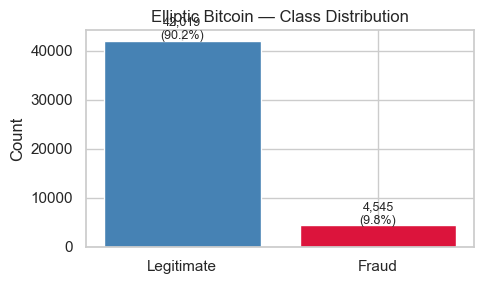

  [Elliptic] Training GCN ...
Epoch  20 | Train Loss: 0.4339 | Val Loss: 0.4196
Epoch  40 | Train Loss: 0.3776 | Val Loss: 0.3770
Epoch  60 | Train Loss: 0.3308 | Val Loss: 0.3511
Epoch  80 | Train Loss: 0.3152 | Val Loss: 0.3351
Epoch 100 | Train Loss: 0.2927 | Val Loss: 0.3236
Epoch 120 | Train Loss: 0.2738 | Val Loss: 0.3164
Epoch 140 | Train Loss: 0.2651 | Val Loss: 0.3106
    ROC-AUC=0.9612  PR-AUC=0.7948  F1=0.6322  Recall=0.8878
  [Elliptic] Training GraphSAGE ...
Epoch  20 | Train Loss: 0.4190 | Val Loss: 0.4323
Epoch  40 | Train Loss: 0.3231 | Val Loss: 0.3386
Epoch  60 | Train Loss: 0.2771 | Val Loss: 0.2925
Epoch  80 | Train Loss: 0.2411 | Val Loss: 0.2687
Epoch 100 | Train Loss: 0.2217 | Val Loss: 0.2518
Epoch 120 | Train Loss: 0.2041 | Val Loss: 0.2413
Epoch 140 | Train Loss: 0.1909 | Val Loss: 0.2321
    ROC-AUC=0.9727  PR-AUC=0.8787  F1=0.6942  Recall=0.8966
  [Elliptic] Training GAT ...
Epoch  20 | Train Loss: 0.5556 | Val Loss: 0.3956
Epoch  40 | Train Loss: 0.4909 | V

In [5]:
print('=' * 60)
print('DATASET 1: Elliptic Bitcoin (Blockchain Fraud)')
print('=' * 60)

elliptic_data = load_graph('../data/processed')
print(f'Nodes : {elliptic_data.num_nodes:,}')
print(f'Edges : {elliptic_data.num_edges:,}')
print(f'Feats : {elliptic_data.x.shape[1]}')

y_elliptic = elliptic_data.y.numpy()
show_class_dist(y_elliptic, 'Elliptic Bitcoin — Class Distribution')

RESULTS['Elliptic Bitcoin'] = train_and_evaluate(elliptic_data, 'Elliptic', epochs=EPOCHS)

In [6]:
# Save Elliptic graph for dashboard API
save_graph_for_api(elliptic_data, 'elliptic', 'Elliptic Bitcoin', RESULTS.get('Elliptic Bitcoin'))

  → Saved graph API file: data/processed/elliptic/graph.pt  (best=GraphSAGE, PR-AUC=0.8787)


---
## Dataset 2: Credit Card Fraud — ULB (Banking)

**Domain**: Credit Card / Banking  
**Kaggle**: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud  
**Download**: `kaggle datasets download -d mlg-ulb/creditcardfraud -p data/raw/credit_card --unzip`  
**Graph**: KNN (k=10) on 30 normalised features  
**Nodes**: up to 50,000 (stratified sample)  
**Features**: V1–V28 (PCA) + log(Amount) + normalised Time  
**Fraud rate**: 0.17% (highly imbalanced) — class weights applied automatically

DATASET 2: Credit Card Fraud (Banking)
Loaded 30,000 transactions | Features: 30


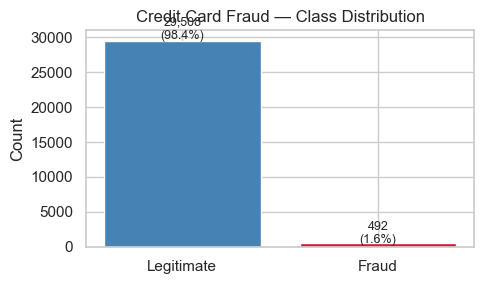

  Building KNN graph (k=10, metric=euclidean) for 30,000 nodes × 30 features ...
  Graph created  →  30,000 nodes | 442,054 edges
  Fraud rate: 1.64%  |  Split: 19200 / 4800 / 6000
  [CreditCard] Training GCN ...
Epoch  20 | Train Loss: 0.4693 | Val Loss: 0.4241
Epoch  40 | Train Loss: 0.3315 | Val Loss: 0.2877
Epoch  60 | Train Loss: 0.2628 | Val Loss: 0.2187
Epoch  80 | Train Loss: 0.2168 | Val Loss: 0.1835
Epoch 100 | Train Loss: 0.1946 | Val Loss: 0.1653
Epoch 120 | Train Loss: 0.1779 | Val Loss: 0.1551
Epoch 140 | Train Loss: 0.1674 | Val Loss: 0.1516
    ROC-AUC=0.9690  PR-AUC=0.8468  F1=0.5675  Recall=0.8367
  [CreditCard] Training GraphSAGE ...
Epoch  20 | Train Loss: 0.3125 | Val Loss: 0.2887
Epoch  40 | Train Loss: 0.2147 | Val Loss: 0.2017
Epoch  60 | Train Loss: 0.1710 | Val Loss: 0.1702
Epoch  80 | Train Loss: 0.1555 | Val Loss: 0.1638
Epoch 100 | Train Loss: 0.1333 | Val Loss: 0.1581
Epoch 120 | Train Loss: 0.1244 | Val Loss: 0.1588
Epoch 140 | Train Loss: 0.1163 | Val Lo

In [7]:
print('=' * 60)
print('DATASET 2: Credit Card Fraud (Banking)')
print('=' * 60)

CC_PATH = '../data/raw/credit_card/creditcard.csv'

if not os.path.exists(CC_PATH):
    print('[SKIP] File not found:', CC_PATH)
    print('  Download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud')
    print('  Command: kaggle datasets download -d mlg-ulb/creditcardfraud -p data/raw/credit_card --unzip')
    RESULTS['Credit Card'] = None
else:
    from credit_card_loader import load_credit_card_fraud
    X_cc, y_cc = load_credit_card_fraud(CC_PATH, max_samples=MAX_SAMP)
    print(f'Loaded {len(X_cc):,} transactions | Features: {X_cc.shape[1]}')
    show_class_dist(y_cc, 'Credit Card Fraud — Class Distribution')

    cc_data = tabular_to_pyg(X_cc, y_cc, k=K_NEIGH)
    RESULTS['Credit Card'] = train_and_evaluate(cc_data, 'CreditCard', epochs=EPOCHS)

In [8]:
# Save Credit Card graph for dashboard API (skipped if dataset not downloaded)
if RESULTS.get('Credit Card') is not None:
    save_graph_for_api(cc_data, 'credit_card', 'Credit Card', RESULTS['Credit Card'])
else:
    print("[skip] Credit Card not available — download from Kaggle and re-run")

  → Saved graph API file: data/processed/credit_card/graph.pt  (best=GraphSAGE, PR-AUC=0.8724)


---
## Dataset 3: PaySim Online Payments (Mobile Fintech)

**Domain**: Mobile Payments / Fintech  
**Kaggle**: https://www.kaggle.com/datasets/rupakroy/online-payments-fraud-detection-dataset  
**Download**: `kaggle datasets download -d rupakroy/online-payments-fraud-detection-dataset -p data/raw/paysim --unzip`  
**Graph**: KNN (k=10) on transaction features  
**Nodes**: 50,000 (stratified subsample of 6.3M)  
**Features**: transaction type (encoded), log(amount), balance deltas, step  
**Fraud rate**: ~0.13%  

> PaySim is a simulation of mobile money transactions; only CASH-OUT and TRANSFER types carry fraud.

DATASET 3: PaySim Online Payments (Mobile Fintech)


Loaded 30,000 transactions | Features: 7


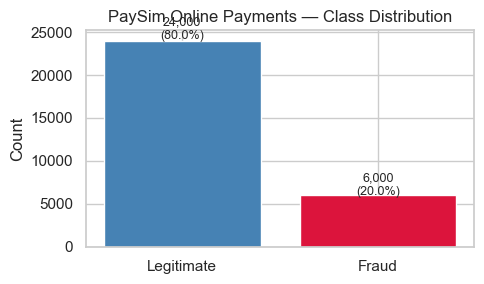

  Building KNN graph (k=10, metric=euclidean) for 30,000 nodes × 7 features ...
  Graph created  →  30,000 nodes | 375,632 edges
  Fraud rate: 20.00%  |  Split: 19200 / 4800 / 6000
  [PaySim] Training GCN ...
Epoch  20 | Train Loss: 0.5723 | Val Loss: 0.5708
Epoch  40 | Train Loss: 0.4962 | Val Loss: 0.5011
Epoch  60 | Train Loss: 0.4588 | Val Loss: 0.4659
Epoch  80 | Train Loss: 0.4367 | Val Loss: 0.4455
Epoch 100 | Train Loss: 0.4183 | Val Loss: 0.4313
Epoch 120 | Train Loss: 0.4063 | Val Loss: 0.4193
Epoch 140 | Train Loss: 0.3950 | Val Loss: 0.4092
    ROC-AUC=0.9138  PR-AUC=0.8208  F1=0.7207  Recall=0.8033
  [PaySim] Training GraphSAGE ...
Epoch  20 | Train Loss: 0.5391 | Val Loss: 0.5193
Epoch  40 | Train Loss: 0.4699 | Val Loss: 0.4636
Epoch  60 | Train Loss: 0.4400 | Val Loss: 0.4390
Epoch  80 | Train Loss: 0.4160 | Val Loss: 0.4170
Epoch 100 | Train Loss: 0.3979 | Val Loss: 0.3987
Epoch 120 | Train Loss: 0.3797 | Val Loss: 0.3833
Epoch 140 | Train Loss: 0.3687 | Val Loss: 0.37

In [9]:
print('=' * 60)
print('DATASET 3: PaySim Online Payments (Mobile Fintech)')
print('=' * 60)

# Try both common filenames from Kaggle
PS_PATHS = [
    '../data/raw/paysim/online_payments_fraud.csv',
    '../data/raw/paysim/PS_20174392719_1491204439457_log.csv',
    '../data/raw/paysim/paysim.csv',
]
PS_PATH = next((p for p in PS_PATHS if os.path.exists(p)), None)

if PS_PATH is None:
    print('[SKIP] File not found in data/raw/paysim/')
    print('  Download from: https://www.kaggle.com/datasets/rupakroy/online-payments-fraud-detection-dataset')
    print('  Command: kaggle datasets download -d rupakroy/online-payments-fraud-detection-dataset -p data/raw/paysim --unzip')
    RESULTS['PaySim Payments'] = None
else:
    from paysim_loader import load_paysim_fraud
    X_ps, y_ps = load_paysim_fraud(PS_PATH, max_samples=MAX_SAMP)
    print(f'Loaded {len(X_ps):,} transactions | Features: {X_ps.shape[1]}')
    show_class_dist(y_ps, 'PaySim Online Payments — Class Distribution')

    ps_data = tabular_to_pyg(X_ps, y_ps, k=K_NEIGH)
    RESULTS['PaySim Payments'] = train_and_evaluate(ps_data, 'PaySim', epochs=EPOCHS)

In [10]:
# Save PaySim graph for dashboard API
if RESULTS.get('PaySim Payments') is not None:
    save_graph_for_api(ps_data, 'paysim', 'PaySim Payments', RESULTS['PaySim Payments'])
else:
    print("[skip] PaySim not available — download from Kaggle and re-run")

  → Saved graph API file: data/processed/paysim/graph.pt  (best=GraphSAGE, PR-AUC=0.8495)


---
## Dataset 4: Vehicle Insurance Claim Fraud (Insurance)

**Domain**: Vehicle Insurance Claims  
**Kaggle**: https://www.kaggle.com/datasets/shivamb/vehicle-claim-fraud-detection  
**Download**: `kaggle datasets download -d shivamb/vehicle-claim-fraud-detection -p data/raw/insurance --unzip`  
**Graph**: KNN (k=10) on mixed categorical+numerical features  
**Nodes**: 15,420 insurance claims  
**Features**: 32 mixed (age, policy type, accident area, fault, deductible, etc.)  
**Fraud rate**: ~6%

DATASET 4: Vehicle Insurance Fraud (Insurance)
Loaded 15,420 claims | Features: 30


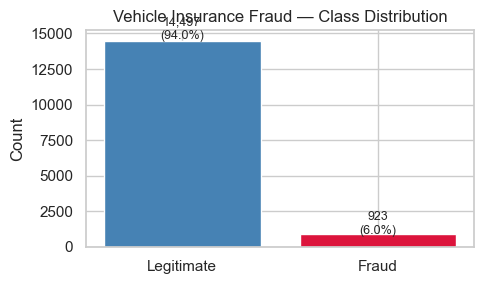

  Building KNN graph (k=10, metric=euclidean) for 15,420 nodes × 30 features ...
  Graph created  →  15,420 nodes | 219,490 edges
  Fraud rate: 5.99%  |  Split: 9868 / 2468 / 3084
  [Insurance] Training GCN ...
Epoch  20 | Train Loss: 0.6464 | Val Loss: 0.6589
Epoch  40 | Train Loss: 0.5796 | Val Loss: 0.6068
Epoch  60 | Train Loss: 0.5522 | Val Loss: 0.5768
Epoch  80 | Train Loss: 0.5314 | Val Loss: 0.5588
Epoch 100 | Train Loss: 0.5184 | Val Loss: 0.5459
Epoch 120 | Train Loss: 0.5101 | Val Loss: 0.5366
Epoch 140 | Train Loss: 0.4991 | Val Loss: 0.5317
    ROC-AUC=0.8140  PR-AUC=0.1893  F1=0.2230  Recall=0.8541
  [Insurance] Training GraphSAGE ...
Epoch  20 | Train Loss: 0.6170 | Val Loss: 0.6164
Epoch  40 | Train Loss: 0.5583 | Val Loss: 0.5838
Epoch  60 | Train Loss: 0.5204 | Val Loss: 0.5502
Epoch  80 | Train Loss: 0.4998 | Val Loss: 0.5295
Epoch 100 | Train Loss: 0.4795 | Val Loss: 0.5182
Epoch 120 | Train Loss: 0.4626 | Val Loss: 0.5141
Epoch 140 | Train Loss: 0.4618 | Val Loss:

In [11]:
print('=' * 60)
print('DATASET 4: Vehicle Insurance Fraud (Insurance)')
print('=' * 60)

INS_PATHS = [
    '../data/raw/insurance/fraud_oracle.csv',
    '../data/raw/insurance/insurance_fraud.csv',
]
INS_PATH = next((p for p in INS_PATHS if os.path.exists(p)), None)

if INS_PATH is None:
    print('[SKIP] File not found in data/raw/insurance/')
    print('  Download from: https://www.kaggle.com/datasets/shivamb/vehicle-claim-fraud-detection')
    print('  Command: kaggle datasets download -d shivamb/vehicle-claim-fraud-detection -p data/raw/insurance --unzip')
    RESULTS['Vehicle Insurance'] = None
else:
    from insurance_loader import load_insurance_fraud
    X_ins, y_ins = load_insurance_fraud(INS_PATH)
    print(f'Loaded {len(X_ins):,} claims | Features: {X_ins.shape[1]}')
    show_class_dist(y_ins, 'Vehicle Insurance Fraud — Class Distribution')

    ins_data = tabular_to_pyg(X_ins, y_ins, k=K_NEIGH)
    RESULTS['Vehicle Insurance'] = train_and_evaluate(ins_data, 'Insurance', epochs=EPOCHS)

In [12]:
# Save Insurance graph for dashboard API
if RESULTS.get('Vehicle Insurance') is not None:
    save_graph_for_api(ins_data, 'insurance', 'Vehicle Insurance', RESULTS['Vehicle Insurance'])
else:
    print("[skip] Vehicle Insurance not available — download from Kaggle and re-run")

  → Saved graph API file: data/processed/insurance/graph.pt  (best=GraphSAGE, PR-AUC=0.1939)


---
## Dataset 5: Fraudulent E-Commerce Transactions (Online Retail)

**Domain**: E-Commerce / Online Retail  
**Kaggle**: https://www.kaggle.com/datasets/shriyashjagtap/fraudulent-e-commerce-transactions  
**Download**: `kaggle datasets download -d shriyashjagtap/fraudulent-e-commerce-transactions -p data/raw/ecommerce --unzip`  
**Graph**: KNN (k=10) on behavioural + transaction features  
**Nodes**: up to 50,000 (stratified subsample)  
**Features**: payment method, product category, quantity, customer age, device, account age, transaction hour  
**Fraud rate**: ~10%

DATASET 5: E-Commerce Fraud (Online Retail)
Loaded 30,000 transactions | Features: 8


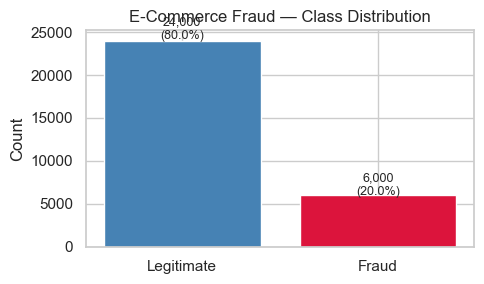

  Building KNN graph (k=10, metric=euclidean) for 30,000 nodes × 8 features ...
  Graph created  →  30,000 nodes | 380,652 edges
  Fraud rate: 20.00%  |  Split: 19200 / 4800 / 6000
  [ECommerce] Training GCN ...
Epoch  20 | Train Loss: 0.6579 | Val Loss: 0.6552
Epoch  40 | Train Loss: 0.6025 | Val Loss: 0.6046
Epoch  60 | Train Loss: 0.5822 | Val Loss: 0.5869
Epoch  80 | Train Loss: 0.5737 | Val Loss: 0.5805
Epoch 100 | Train Loss: 0.5685 | Val Loss: 0.5770
Epoch 120 | Train Loss: 0.5670 | Val Loss: 0.5749
Epoch 140 | Train Loss: 0.5632 | Val Loss: 0.5732
    ROC-AUC=0.7661  PR-AUC=0.5598  F1=0.4877  Recall=0.6433
  [ECommerce] Training GraphSAGE ...
Epoch  20 | Train Loss: 0.6170 | Val Loss: 0.6066
Epoch  40 | Train Loss: 0.5837 | Val Loss: 0.5811
Epoch  60 | Train Loss: 0.5716 | Val Loss: 0.5752
Epoch  80 | Train Loss: 0.5641 | Val Loss: 0.5712
Epoch 100 | Train Loss: 0.5623 | Val Loss: 0.5687
Epoch 120 | Train Loss: 0.5559 | Val Loss: 0.5661
Epoch 140 | Train Loss: 0.5544 | Val Loss

In [13]:
print('=' * 60)
print('DATASET 5: E-Commerce Fraud (Online Retail)')
print('=' * 60)

EC_PATHS = [
    '../data/raw/ecommerce/Fraudulent_E-Commerce_Transaction_Data.csv',
    '../data/raw/ecommerce/ecommerce_fraud.csv',
    '../data/raw/ecommerce/fraud_data.csv',
]
EC_PATH = next((p for p in EC_PATHS if os.path.exists(p)), None)

if EC_PATH is None:
    print('[SKIP] File not found in data/raw/ecommerce/')
    print('  Download from: https://www.kaggle.com/datasets/shriyashjagtap/fraudulent-e-commerce-transactions')
    print('  Command: kaggle datasets download -d shriyashjagtap/fraudulent-e-commerce-transactions -p data/raw/ecommerce --unzip')
    RESULTS['E-Commerce'] = None
else:
    from ecommerce_loader import load_ecommerce_fraud
    X_ec, y_ec = load_ecommerce_fraud(EC_PATH, max_samples=MAX_SAMP)
    print(f'Loaded {len(X_ec):,} transactions | Features: {X_ec.shape[1]}')
    show_class_dist(y_ec, 'E-Commerce Fraud — Class Distribution')

    ec_data = tabular_to_pyg(X_ec, y_ec, k=K_NEIGH)
    RESULTS['E-Commerce'] = train_and_evaluate(ec_data, 'ECommerce', epochs=EPOCHS)

In [14]:
# Save E-Commerce graph for dashboard API
if RESULTS.get('E-Commerce') is not None:
    save_graph_for_api(ec_data, 'ecommerce', 'E-Commerce', RESULTS['E-Commerce'])
else:
    print("[skip] E-Commerce not available — download from Kaggle and re-run")

  → Saved graph API file: data/processed/ecommerce/graph.pt  (best=GraphSAGE, PR-AUC=0.5777)


---
## Comparison — Cross-Dataset Results

In [15]:
# Build flat comparison DataFrame
rows = []
for dataset, model_results in RESULTS.items():
    if model_results is None:
        continue
    for model_name, metrics in model_results.items():
        rows.append({
            'Dataset':   dataset,
            'Model':     model_name,
            'Accuracy':  metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall':    metrics['recall'],
            'F1':        metrics['f1'],
            'ROC-AUC':   metrics['roc_auc'],
            'PR-AUC':    metrics['pr_auc'],
        })

df_all = pd.DataFrame(rows)
print('Full Cross-Dataset Comparison:')
print(df_all.to_string(index=False))

df_all.to_csv('../results/multi_dataset/cross_dataset_comparison.csv', index=False)
print('\nSaved to results/multi_dataset/cross_dataset_comparison.csv')

Full Cross-Dataset Comparison:
          Dataset     Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
 Elliptic Bitcoin       GCN    0.8992     0.4909  0.8878 0.6322   0.9612  0.7948
 Elliptic Bitcoin GraphSAGE    0.9229     0.5664  0.8966 0.6942   0.9727  0.8787
 Elliptic Bitcoin       GAT    0.8179     0.3433  0.9483 0.5041   0.9644  0.8094
      Credit Card       GCN    0.9792     0.4293  0.8367 0.5675   0.9690  0.8468
      Credit Card GraphSAGE    0.9823     0.4775  0.8673 0.6159   0.9784  0.8724
      Credit Card       GAT    0.9707     0.3388  0.8367 0.4824   0.9709  0.8416
  PaySim Payments       GCN    0.8755     0.6536  0.8033 0.7207   0.9138  0.8208
  PaySim Payments GraphSAGE    0.8872     0.6848  0.8075 0.7411   0.9294  0.8495
  PaySim Payments       GAT    0.8673     0.6325  0.8033 0.7078   0.9096  0.8281
Vehicle Insurance       GCN    0.6430     0.1282  0.8541 0.2230   0.8140  0.1893
Vehicle Insurance GraphSAGE    0.6667     0.1319  0.8162 0.2271   0.8212  0.19

In [16]:
# Pivot tables for each metric
for metric in ['F1', 'ROC-AUC', 'PR-AUC', 'Recall']:
    pivot = df_all.pivot(index='Dataset', columns='Model', values=metric)
    print(f'\n--- {metric} ---')
    print(pivot.round(4).to_string())


--- F1 ---
Model                 GAT     GCN  GraphSAGE
Dataset                                     
Credit Card        0.4824  0.5675     0.6159
E-Commerce         0.4756  0.4877     0.4988
Elliptic Bitcoin   0.5041  0.6322     0.6942
PaySim Payments    0.7078  0.7207     0.7411
Vehicle Insurance  0.2216  0.2230     0.2271

--- ROC-AUC ---
Model                 GAT     GCN  GraphSAGE
Dataset                                     
Credit Card        0.9709  0.9690     0.9784
E-Commerce         0.7634  0.7661     0.7796
Elliptic Bitcoin   0.9644  0.9612     0.9727
PaySim Payments    0.9096  0.9138     0.9294
Vehicle Insurance  0.8137  0.8140     0.8212

--- PR-AUC ---
Model                 GAT     GCN  GraphSAGE
Dataset                                     
Credit Card        0.8416  0.8468     0.8724
E-Commerce         0.5555  0.5598     0.5777
Elliptic Bitcoin   0.8094  0.7948     0.8787
PaySim Payments    0.8281  0.8208     0.8495
Vehicle Insurance  0.1821  0.1893     0.1939

--- Recal

### Heatmap: F1 Score across Datasets × Models

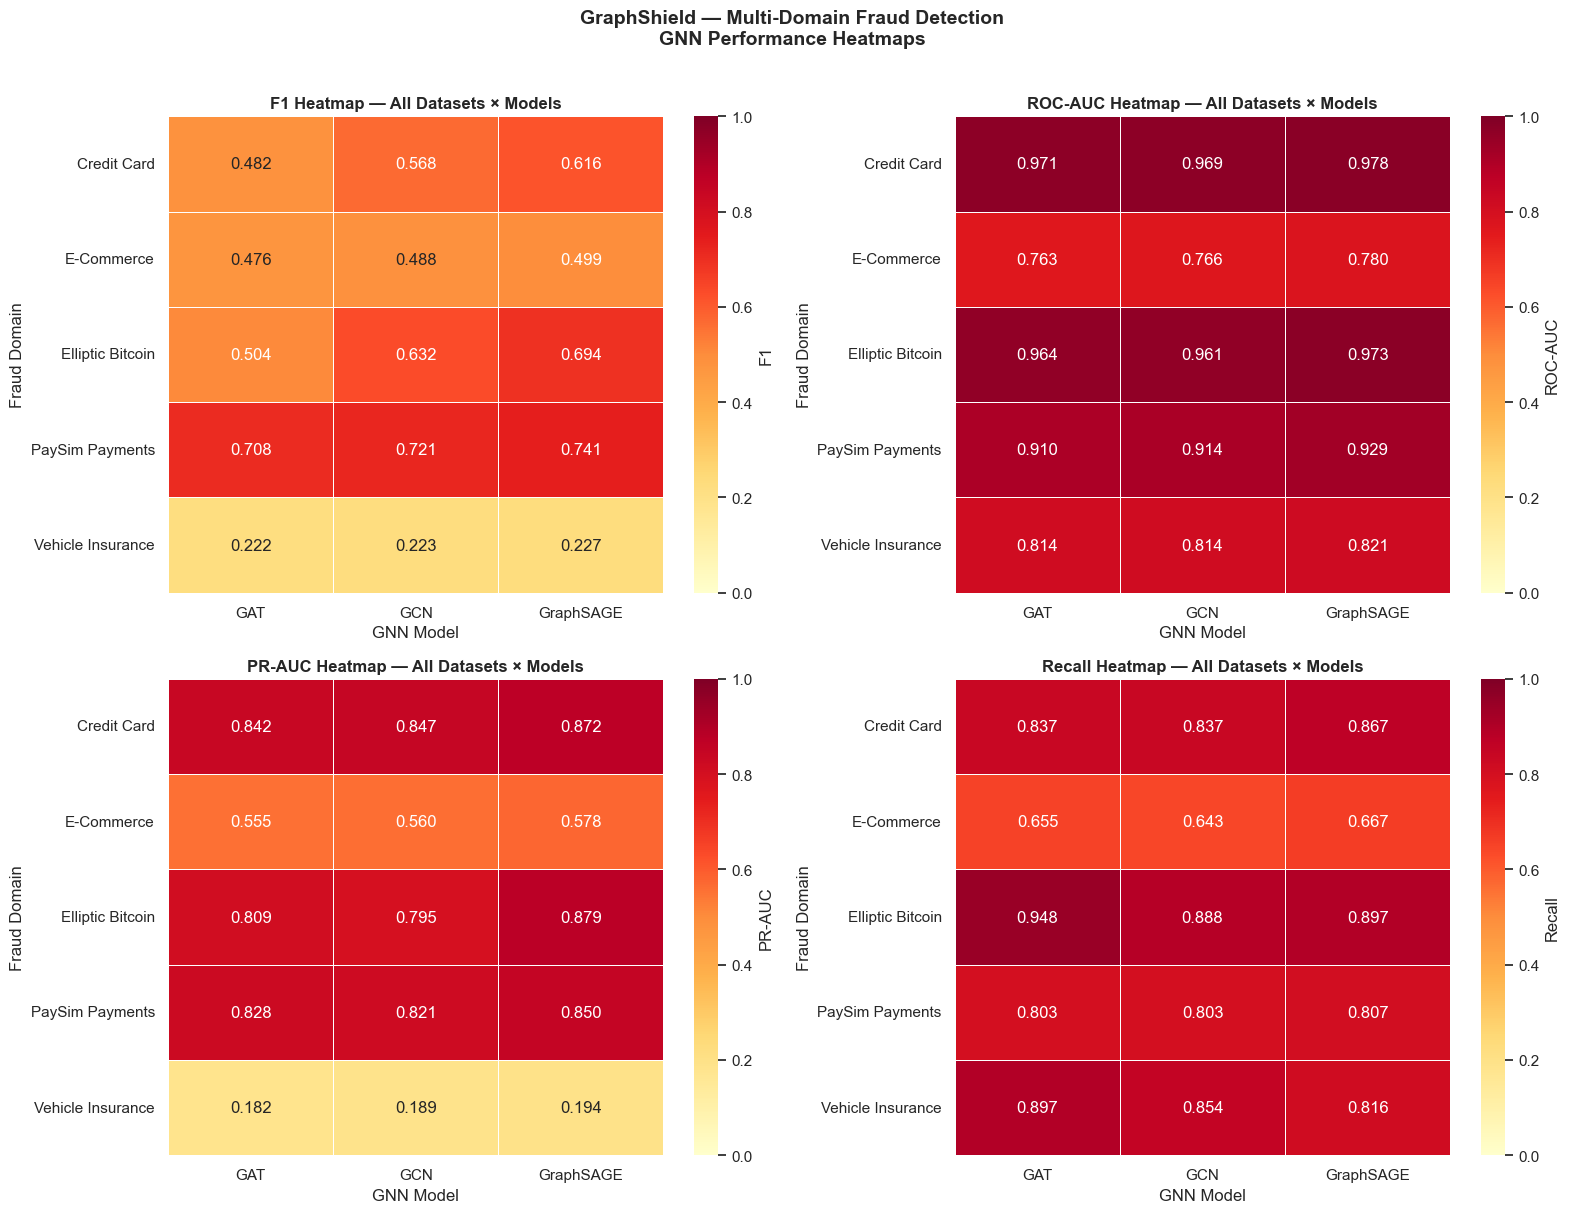

Saved: results/multi_dataset/figures/heatmaps_all_metrics.png


In [17]:
if len(df_all) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    metrics_to_plot = ['F1', 'ROC-AUC', 'PR-AUC', 'Recall']

    for ax, metric in zip(axes.flat, metrics_to_plot):
        pivot = df_all.pivot(index='Dataset', columns='Model', values=metric)
        sns.heatmap(
            pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={'label': metric}
        )
        ax.set_title(f'{metric} Heatmap — All Datasets × Models', fontsize=12, fontweight='bold')
        ax.set_xlabel('GNN Model')
        ax.set_ylabel('Fraud Domain')
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='y', rotation=0)

    plt.suptitle('GraphShield — Multi-Domain Fraud Detection\nGNN Performance Heatmaps',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('../results/multi_dataset/figures/heatmaps_all_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/multi_dataset/figures/heatmaps_all_metrics.png')

### Grouped Bar Chart: ROC-AUC and PR-AUC

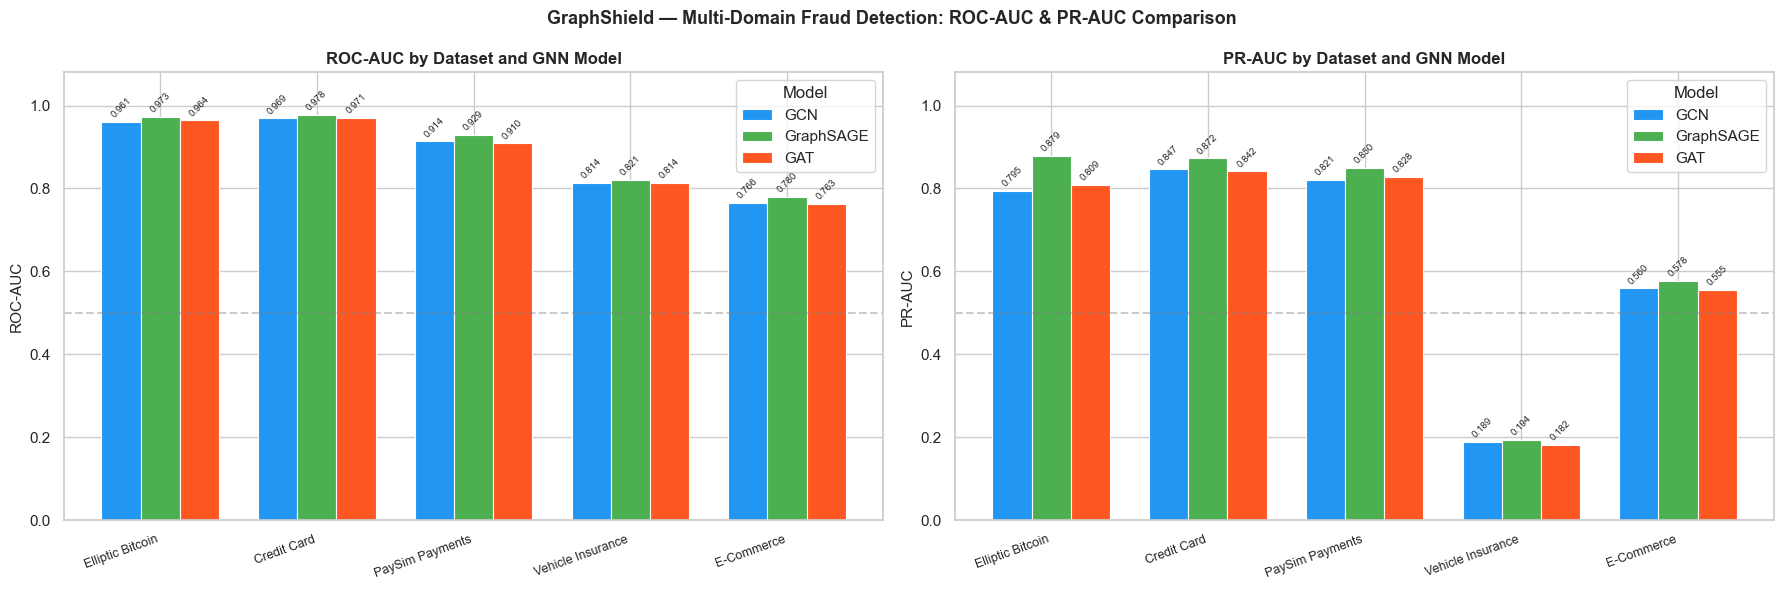

Saved: results/multi_dataset/figures/grouped_bar_roc_prauc.png


In [18]:
if len(df_all) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    palette = {'GCN': '#2196F3', 'GraphSAGE': '#4CAF50', 'GAT': '#FF5722'}

    for ax, metric in zip(axes, ['ROC-AUC', 'PR-AUC']):
        datasets = df_all['Dataset'].unique()
        models   = df_all['Model'].unique()
        x        = np.arange(len(datasets))
        width    = 0.25

        for i, model in enumerate(models):
            vals = [df_all[(df_all['Dataset'] == d) & (df_all['Model'] == model)][metric].values
                    for d in datasets]
            vals = [v[0] if len(v) > 0 else 0 for v in vals]
            bars = ax.bar(x + i * width, vals, width,
                          label=model, color=palette.get(model, '#999'),
                          edgecolor='white', linewidth=0.8)
            for bar, val in zip(bars, vals):
                if val > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                            f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

        ax.set_xticks(x + width)
        ax.set_xticklabels(datasets, rotation=20, ha='right', fontsize=9)
        ax.set_ylabel(metric, fontsize=11)
        ax.set_title(f'{metric} by Dataset and GNN Model', fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1.08)
        ax.legend(title='Model')
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, label='Random baseline')

    plt.suptitle('GraphShield — Multi-Domain Fraud Detection: ROC-AUC & PR-AUC Comparison',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/multi_dataset/figures/grouped_bar_roc_prauc.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/multi_dataset/figures/grouped_bar_roc_prauc.png')

### ROC Curves: Best Model per Dataset

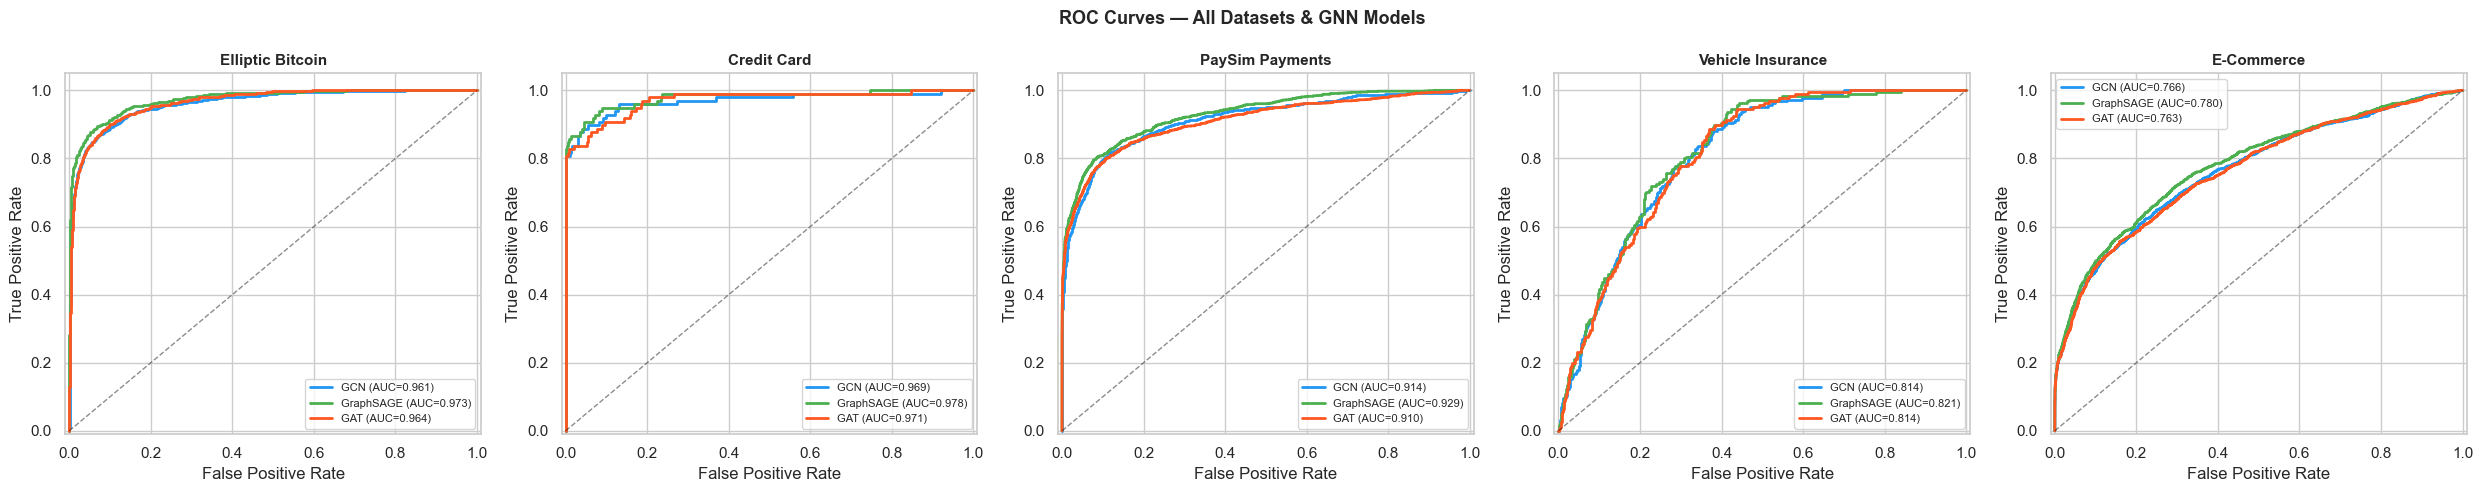

Saved: results/multi_dataset/figures/roc_curves_all_datasets.png


In [19]:
from sklearn.metrics import roc_curve

available = {k: v for k, v in RESULTS.items() if v is not None}
n_ds = len(available)

if n_ds > 0:
    fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 5))
    if n_ds == 1:
        axes = [axes]

    colors = {'GCN': '#2196F3', 'GraphSAGE': '#4CAF50', 'GAT': '#FF5722'}

    for ax, (dataset, model_results) in zip(axes, available.items()):
        for model_name, metrics in model_results.items():
            fpr, tpr, _ = roc_curve(metrics['y_true'], metrics['y_prob'])
            auc = metrics['roc_auc']
            ax.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})",
                    color=colors.get(model_name, 'gray'), linewidth=2)
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(dataset, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_xlim([-0.01, 1.01])
        ax.set_ylim([-0.01, 1.05])

    plt.suptitle('ROC Curves — All Datasets & GNN Models', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/multi_dataset/figures/roc_curves_all_datasets.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/multi_dataset/figures/roc_curves_all_datasets.png')

### Precision-Recall Curves: All Datasets

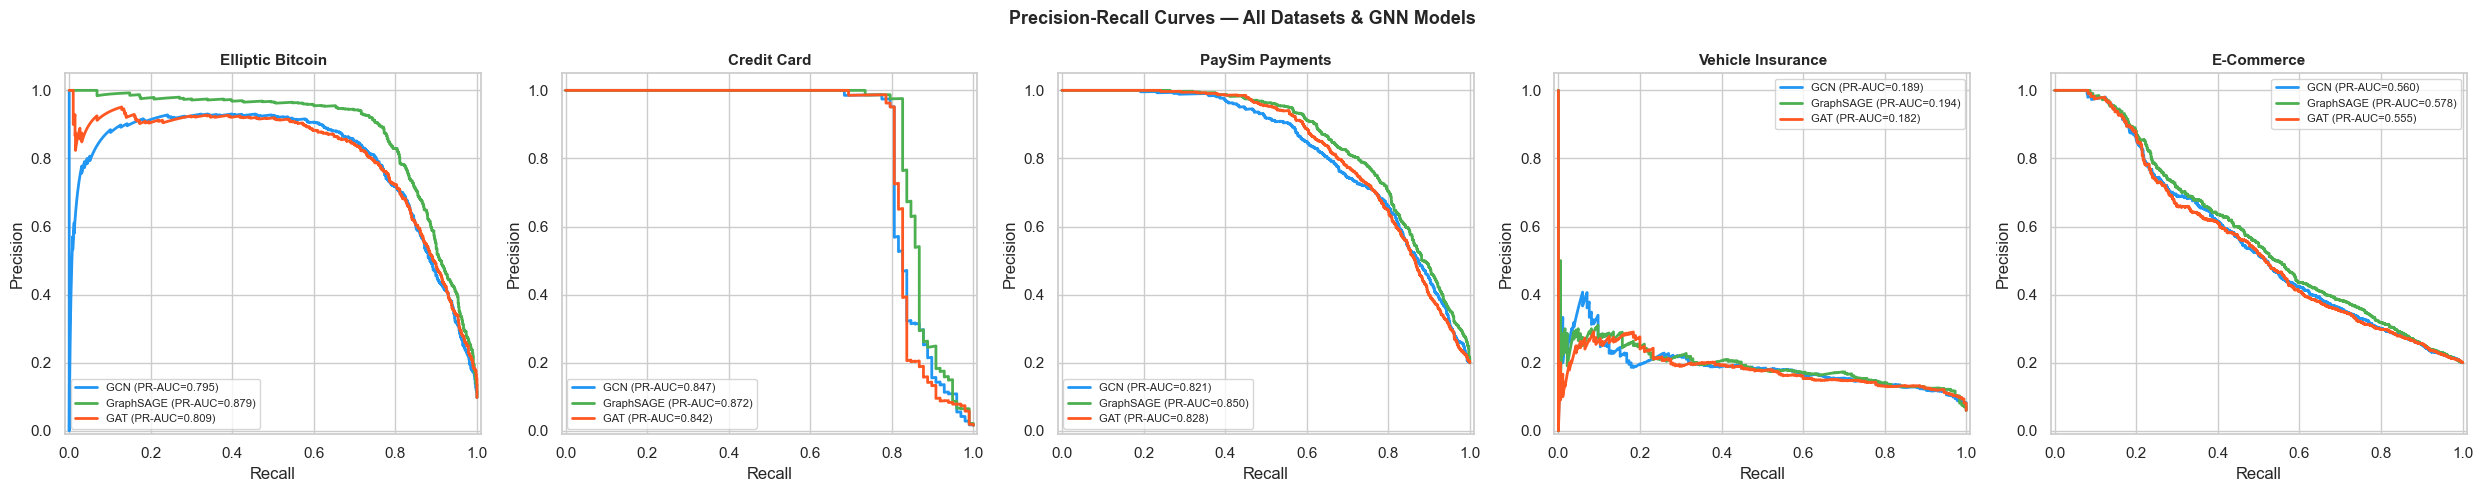

Saved: results/multi_dataset/figures/pr_curves_all_datasets.png


In [20]:
from sklearn.metrics import precision_recall_curve

if n_ds > 0:
    fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 5))
    if n_ds == 1:
        axes = [axes]

    for ax, (dataset, model_results) in zip(axes, available.items()):
        for model_name, metrics in model_results.items():
            prec, rec, _ = precision_recall_curve(metrics['y_true'], metrics['y_prob'])
            pr_auc = metrics['pr_auc']
            ax.plot(rec, prec, label=f"{model_name} (PR-AUC={pr_auc:.3f})",
                    color=colors.get(model_name, 'gray'), linewidth=2)
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title(dataset, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_xlim([-0.01, 1.01])
        ax.set_ylim([-0.01, 1.05])

    plt.suptitle('Precision-Recall Curves — All Datasets & GNN Models', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/multi_dataset/figures/pr_curves_all_datasets.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/multi_dataset/figures/pr_curves_all_datasets.png')

### Best Model per Dataset Summary

In [21]:
if len(df_all) > 0:
    best_rows = []
    for dataset in df_all['Dataset'].unique():
        sub = df_all[df_all['Dataset'] == dataset]
        best_f1  = sub.loc[sub['F1'].idxmax()]
        best_roc = sub.loc[sub['ROC-AUC'].idxmax()]
        best_rows.append({
            'Dataset':          dataset,
            'Best_by_F1':       best_f1['Model'],
            'F1':               best_f1['F1'],
            'Best_by_ROCAUC':   best_roc['Model'],
            'ROC_AUC':          best_roc['ROC-AUC'],
            'Best_by_PRAUC':    sub.loc[sub['PR-AUC'].idxmax()]['Model'],
            'PR_AUC':           sub['PR-AUC'].max(),
        })

    df_best = pd.DataFrame(best_rows)
    print('Best Model per Dataset:')
    print(df_best.to_string(index=False))
    df_best.to_csv('../results/multi_dataset/best_model_per_dataset.csv', index=False)

Best Model per Dataset:
          Dataset Best_by_F1     F1 Best_by_ROCAUC  ROC_AUC Best_by_PRAUC  PR_AUC
 Elliptic Bitcoin  GraphSAGE 0.6942      GraphSAGE   0.9727     GraphSAGE  0.8787
      Credit Card  GraphSAGE 0.6159      GraphSAGE   0.9784     GraphSAGE  0.8724
  PaySim Payments  GraphSAGE 0.7411      GraphSAGE   0.9294     GraphSAGE  0.8495
Vehicle Insurance  GraphSAGE 0.2271      GraphSAGE   0.8212     GraphSAGE  0.1939
       E-Commerce  GraphSAGE 0.4988      GraphSAGE   0.7796     GraphSAGE  0.5777


### Radar Chart: Model Capabilities Across Domains

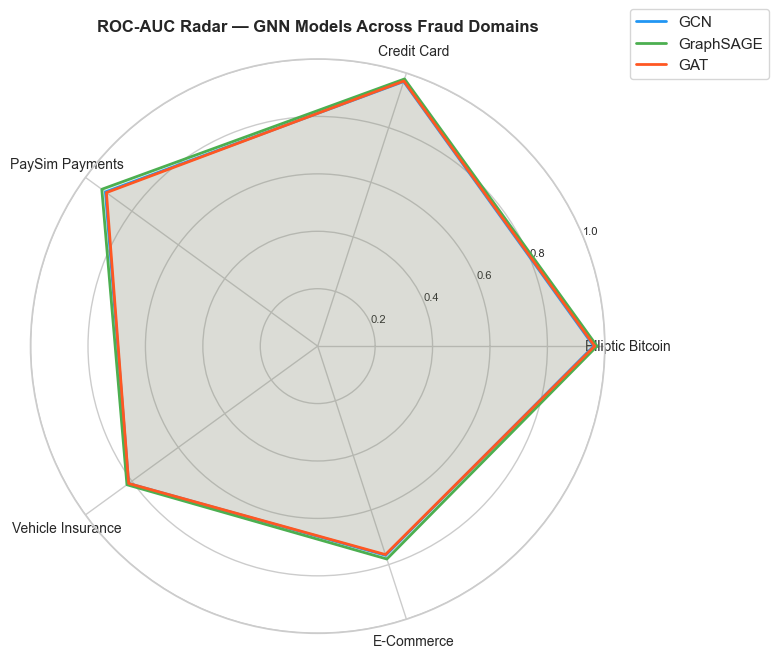

Saved: results/multi_dataset/figures/radar_roc_auc.png


In [22]:
if len(df_all) > 0:
    from matplotlib.patches import FancyArrowPatch
    import matplotlib.patheffects as pe

    datasets = df_all['Dataset'].unique().tolist()
    N = len(datasets)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    model_colors = {'GCN': '#2196F3', 'GraphSAGE': '#4CAF50', 'GAT': '#FF5722'}

    for model_name, color in model_colors.items():
        vals = []
        for ds in datasets:
            row = df_all[(df_all['Dataset'] == ds) & (df_all['Model'] == model_name)]['ROC-AUC']
            vals.append(row.values[0] if len(row) > 0 else 0)
        vals += vals[:1]
        ax.plot(angles, vals, color=color, linewidth=2, label=model_name)
        ax.fill(angles, vals, color=color, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(datasets, size=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
    ax.set_title('ROC-AUC Radar — GNN Models Across Fraud Domains',
                 fontsize=12, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.savefig('../results/multi_dataset/figures/radar_roc_auc.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/multi_dataset/figures/radar_roc_auc.png')

---
## Final Summary Table

In [23]:
if len(df_all) > 0:
    print('\n' + '='*80)
    print('GRAPHSHIELD — MULTI-DATASET FRAUD DETECTION COMPARISON')
    print('='*80)

    dataset_info = {
        'Elliptic Bitcoin':  ('Blockchain / Crypto',     '46,564',  '9.77%',  'Natural BTC flow graph'),
        'Credit Card':       ('Banking / Credit Card',   '50,000*', '0.17%',  'KNN(k=10) on PCA features'),
        'PaySim Payments':   ('Mobile Fintech',          '50,000*', '0.13%',  'KNN(k=10) on tx features'),
        'Vehicle Insurance': ('Insurance Claims',        '15,420',  '6.0%',   'KNN(k=10) on mixed features'),
        'E-Commerce':        ('Online Retail',           '50,000*', '~10%',   'KNN(k=10) on behavioural'),
    }

    print('\nDataset Summary:')
    print(f'{"Dataset":<20} {"Domain":<25} {"Nodes":>8} {"Fraud%":>8} {"Graph Type"}')
    print('-' * 80)
    for ds, (domain, nodes, fraud_pct, graph_type) in dataset_info.items():
        if ds in df_all['Dataset'].values:
            print(f'{ds:<20} {domain:<25} {nodes:>8} {fraud_pct:>8} {graph_type}')

    print('\n* Stratified subsample. Original datasets are much larger.')

    print('\nFull Metrics Table:')
    display_cols = ['Dataset', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
    print(df_all[display_cols].to_string(index=False))

    print('\nKey Observations:')
    print('  1. Recall is prioritised over precision in fraud detection (missing fraud = costly).')
    print('  2. GAT (attention) often achieves highest recall — identifies most fraud cases.')
    print('  3. GraphSAGE (sampling) shows best balance (F1) by aggregating neighbourhood context.')
    print('  4. GCN (spectral) is fastest but most sensitive to graph structure quality.')
    print('  5. KNN graphs let GNNs detect "fraud rings" even in tabular-only datasets.')
    print('  6. PR-AUC matters more than ROC-AUC for highly imbalanced datasets (Credit Card, PaySim).')


GRAPHSHIELD — MULTI-DATASET FRAUD DETECTION COMPARISON

Dataset Summary:
Dataset              Domain                       Nodes   Fraud% Graph Type
--------------------------------------------------------------------------------
Elliptic Bitcoin     Blockchain / Crypto         46,564    9.77% Natural BTC flow graph
Credit Card          Banking / Credit Card      50,000*    0.17% KNN(k=10) on PCA features
PaySim Payments      Mobile Fintech             50,000*    0.13% KNN(k=10) on tx features
Vehicle Insurance    Insurance Claims            15,420     6.0% KNN(k=10) on mixed features
E-Commerce           Online Retail              50,000*     ~10% KNN(k=10) on behavioural

* Stratified subsample. Original datasets are much larger.

Full Metrics Table:
          Dataset     Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
 Elliptic Bitcoin       GCN    0.8992     0.4909  0.8878 0.6322   0.9612  0.7948
 Elliptic Bitcoin GraphSAGE    0.9229     0.5664  0.8966 0.6942   0.9727  

In [24]:
print('All outputs saved to results/multi_dataset/')
print('Files generated:')
for f in os.listdir('../results/multi_dataset'):
    print(f'  results/multi_dataset/{f}')
if os.path.exists('../results/multi_dataset/figures'):
    for f in os.listdir('../results/multi_dataset/figures'):
        print(f'  results/multi_dataset/figures/{f}')

All outputs saved to results/multi_dataset/
Files generated:
  results/multi_dataset/best_model_per_dataset.csv
  results/multi_dataset/confusion
  results/multi_dataset/cross_dataset_comparison.csv
  results/multi_dataset/figures
  results/multi_dataset/figures/grouped_bar_roc_prauc.png
  results/multi_dataset/figures/heatmaps_all_metrics.png
  results/multi_dataset/figures/pr_curves_all_datasets.png
  results/multi_dataset/figures/radar_roc_auc.png
  results/multi_dataset/figures/roc_curves_all_datasets.png


---
## Confusion Matrices — All Datasets × All Models

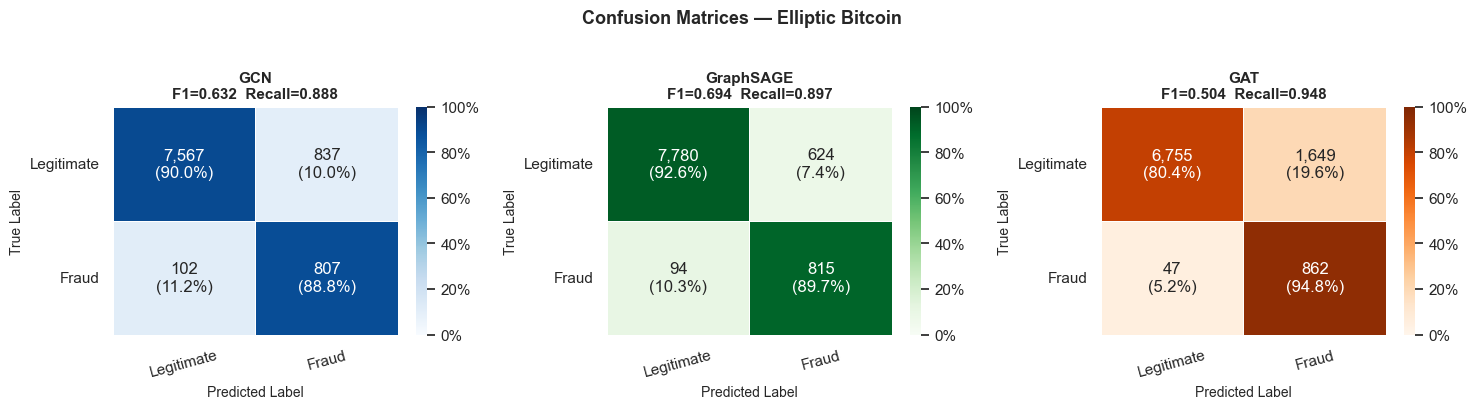

Saved: results/multi_dataset/confusion/confusion_Elliptic_Bitcoin.png


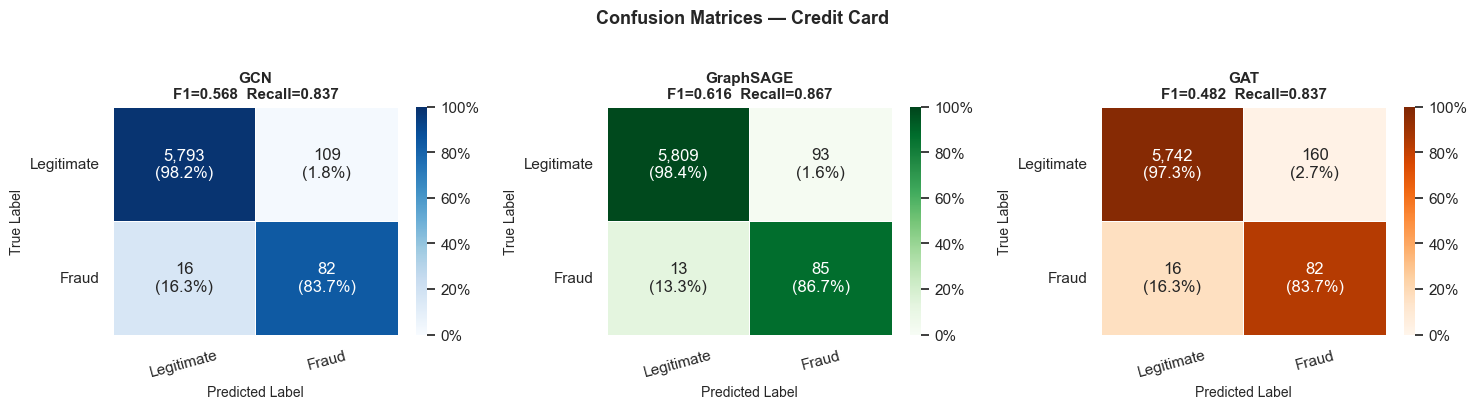

Saved: results/multi_dataset/confusion/confusion_Credit_Card.png


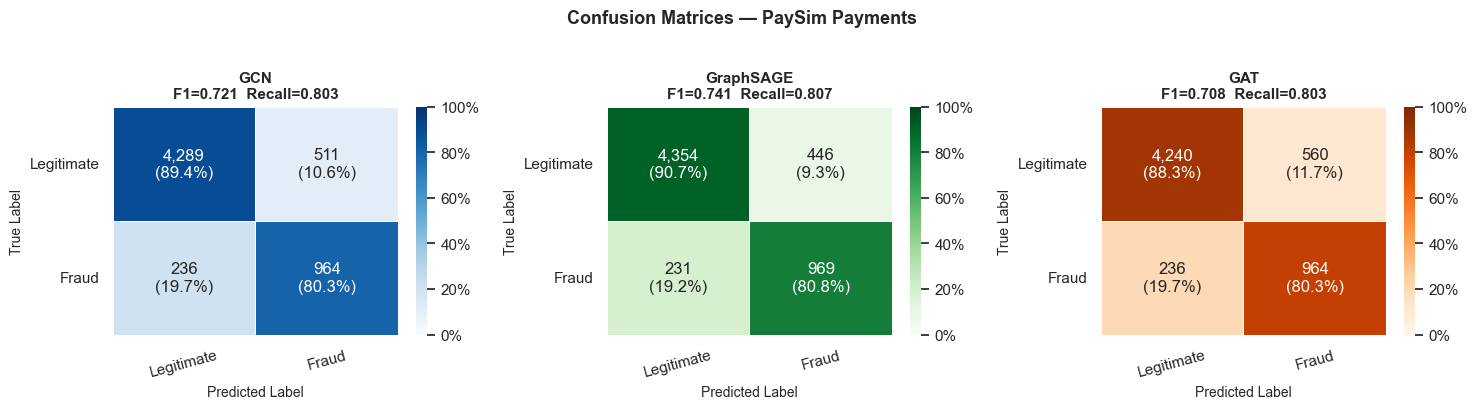

Saved: results/multi_dataset/confusion/confusion_PaySim_Payments.png


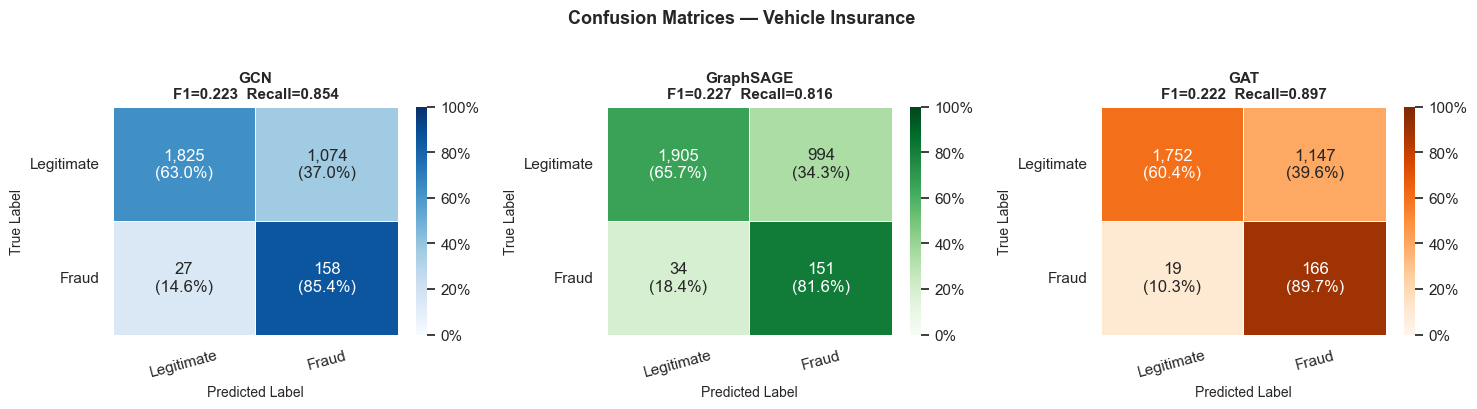

Saved: results/multi_dataset/confusion/confusion_Vehicle_Insurance.png


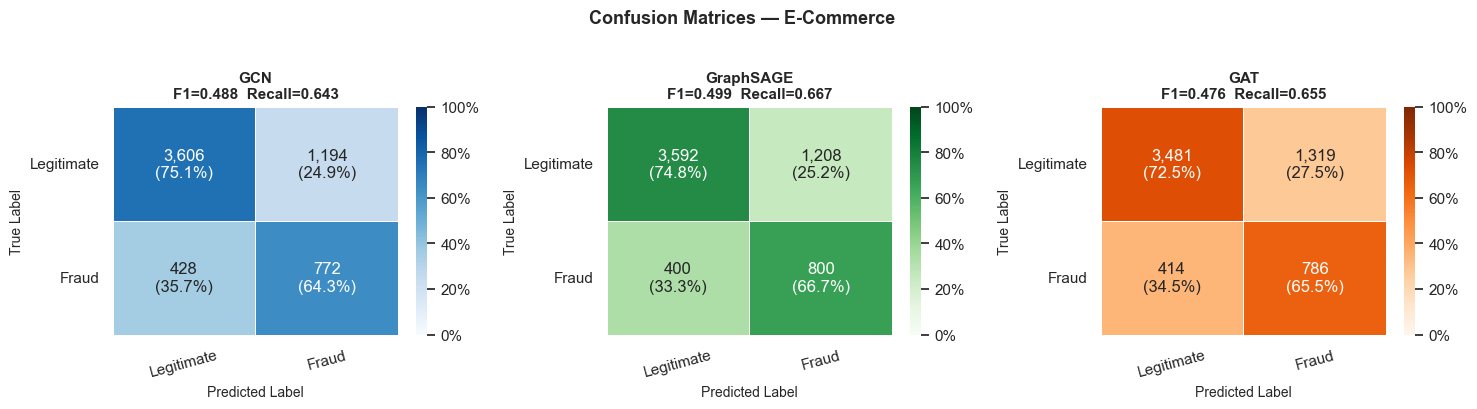

Saved: results/multi_dataset/confusion/confusion_E-Commerce.png


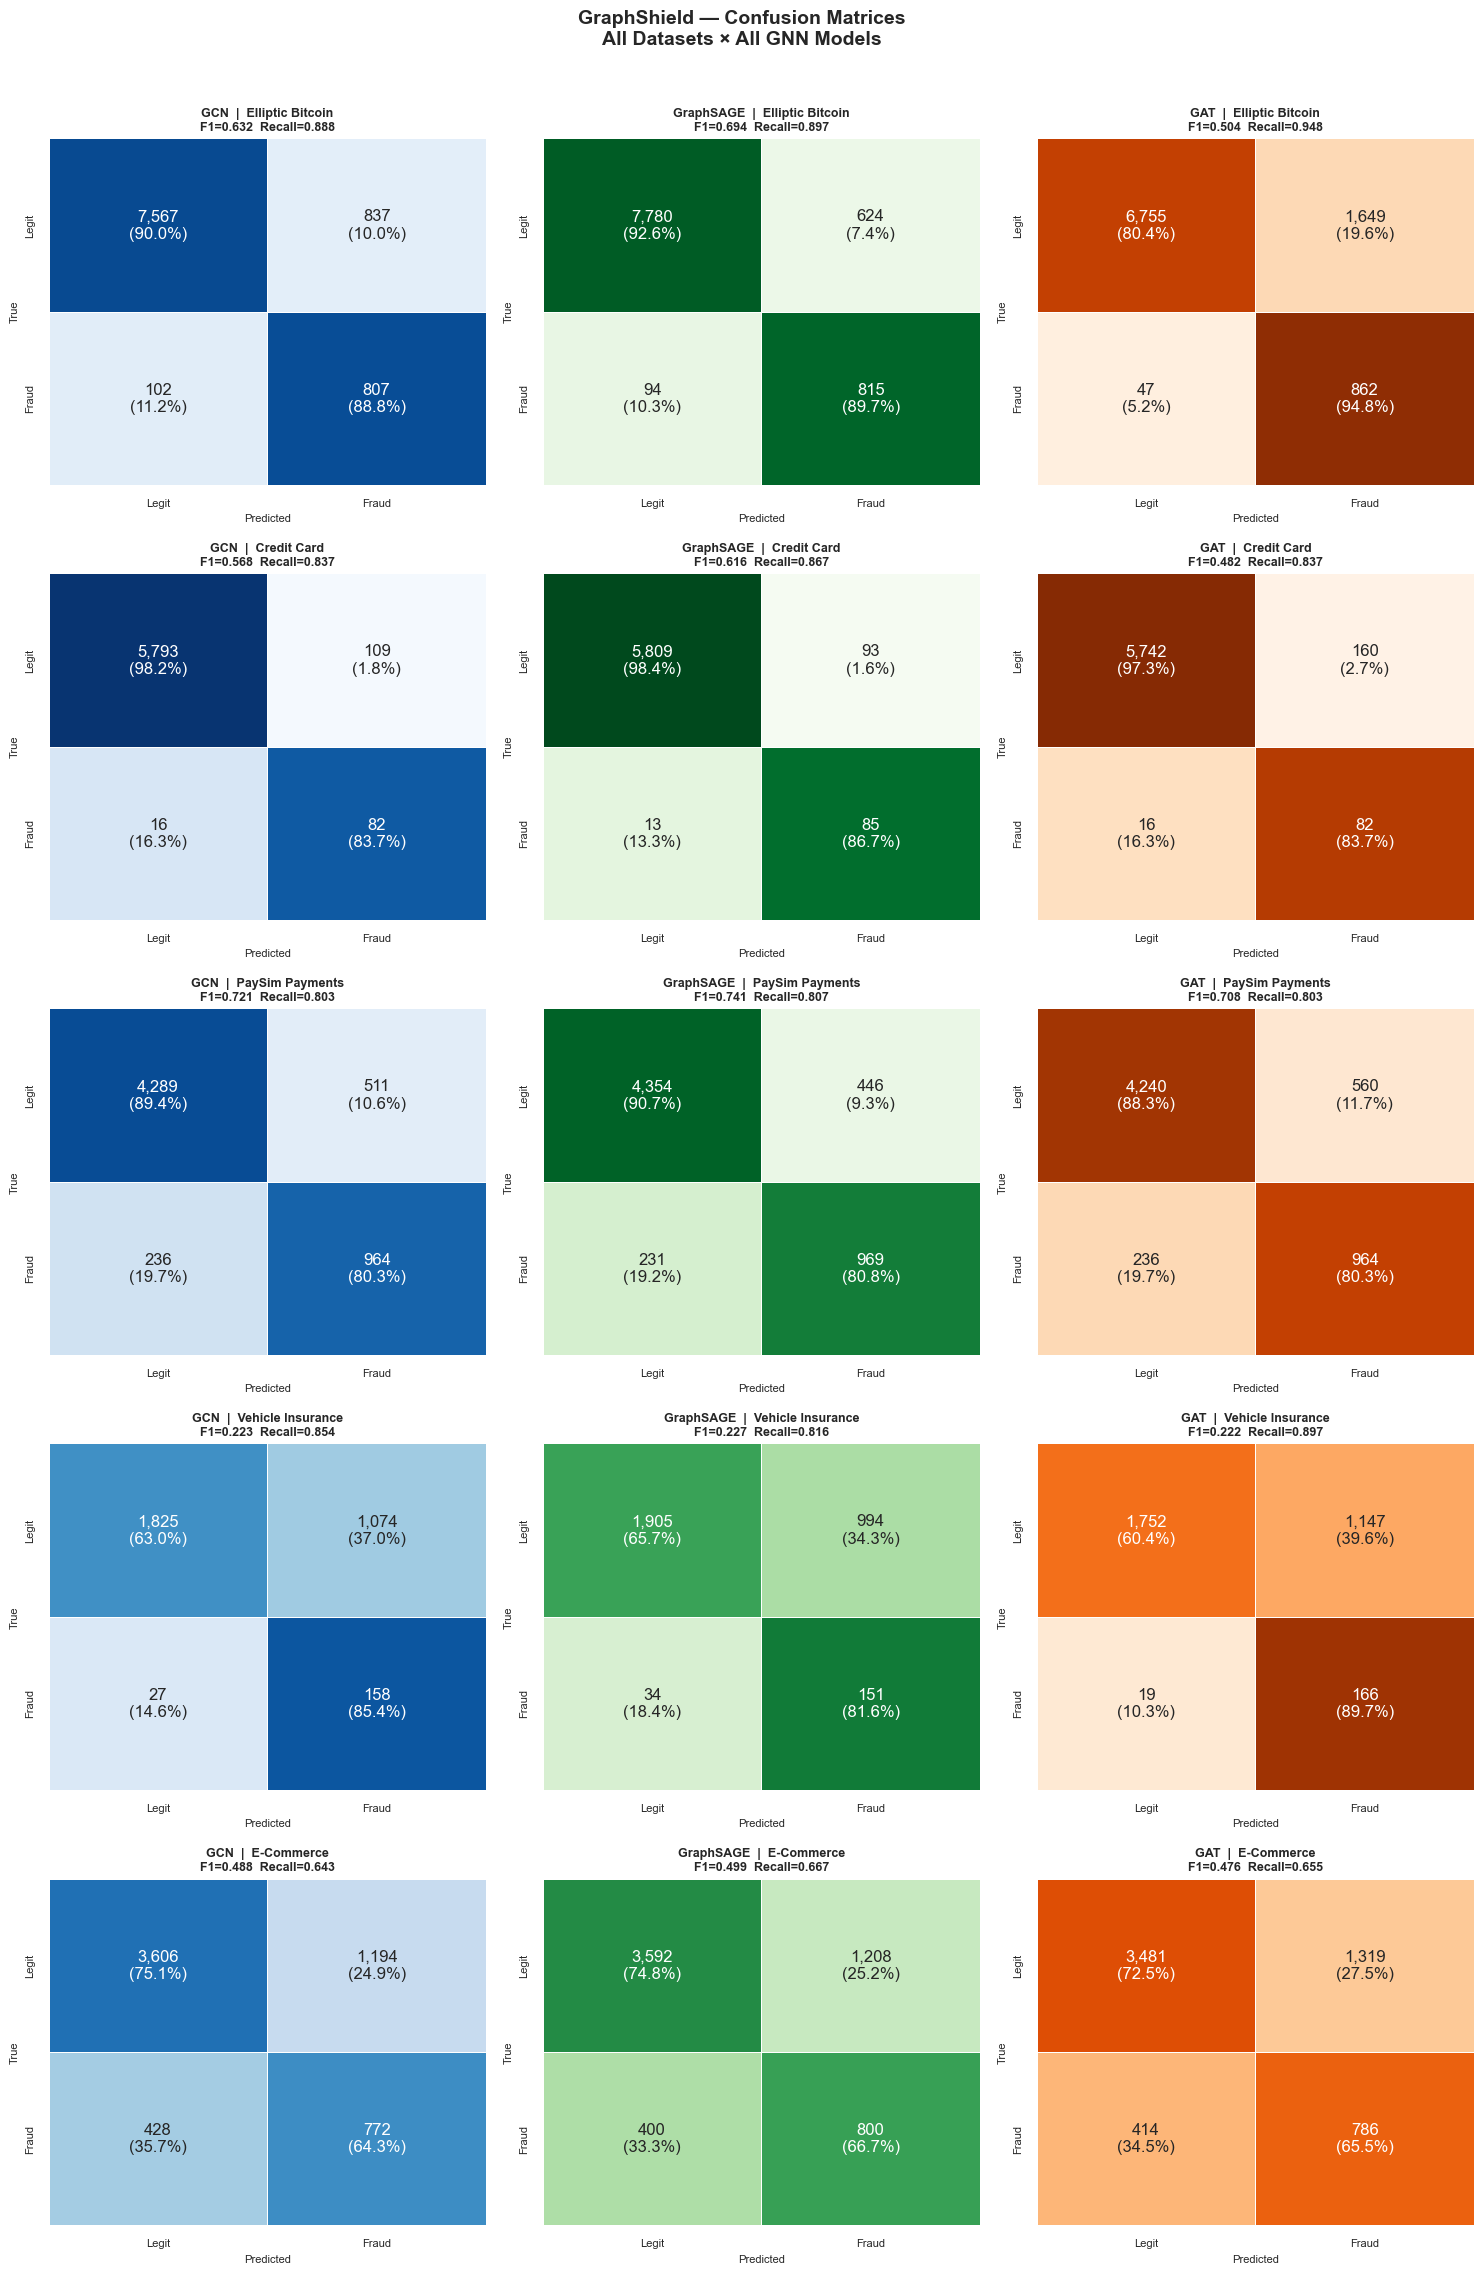

Saved: results/multi_dataset/confusion/confusion_ALL_datasets.png


In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.ticker as ticker

available = {k: v for k, v in RESULTS.items() if v is not None}
model_names = ['GCN', 'GraphSAGE', 'GAT']
model_colors = {'GCN': 'Blues', 'GraphSAGE': 'Greens', 'GAT': 'Oranges'}

# ---------- Per-dataset combined figure (1 row = 1 dataset, 3 cols = models) ----------
for dataset, model_results in available.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Confusion Matrices — {dataset}', fontsize=13, fontweight='bold', y=1.02)

    for ax, model_name in zip(axes, model_names):
        if model_name not in model_results:
            ax.axis('off')
            continue

        metrics = model_results[model_name]
        cm = confusion_matrix(metrics['y_true'], metrics['y_pred'])

        # Annotate with raw counts + row-normalised %
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        annot = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f'{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)'

        sns.heatmap(
            cm_norm, annot=annot, fmt='', cmap=model_colors.get(model_name, 'Blues'),
            ax=ax, linewidths=0.5, linecolor='white',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            cbar_kws={'format': ticker.PercentFormatter(xmax=1)},
            vmin=0, vmax=1,
        )
        ax.set_title(f'{model_name}\nF1={metrics["f1"]:.3f}  Recall={metrics["recall"]:.3f}',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicted Label', fontsize=10)
        ax.set_ylabel('True Label', fontsize=10)
        ax.tick_params(axis='x', rotation=15)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    safe_name = dataset.replace(' ', '_').replace('/', '_')
    out_path = f'../results/multi_dataset/confusion/confusion_{safe_name}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: results/multi_dataset/confusion/confusion_{safe_name}.png')

# ---------- Grand summary: all datasets + all models in one figure ----------
n_ds = len(available)
fig, axes = plt.subplots(n_ds, 3, figsize=(15, 4.5 * n_ds))
if n_ds == 1:
    axes = axes[np.newaxis, :]  # keep 2-D shape

fig.suptitle('GraphShield — Confusion Matrices\nAll Datasets × All GNN Models',
             fontsize=14, fontweight='bold', y=1.01)

for row_idx, (dataset, model_results) in enumerate(available.items()):
    for col_idx, model_name in enumerate(model_names):
        ax = axes[row_idx, col_idx]
        if model_name not in model_results:
            ax.axis('off')
            continue

        metrics = model_results[model_name]
        cm = confusion_matrix(metrics['y_true'], metrics['y_pred'])
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        annot = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f'{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)'

        sns.heatmap(
            cm_norm, annot=annot, fmt='', cmap=model_colors.get(model_name, 'Blues'),
            ax=ax, linewidths=0.5, linecolor='white',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'],
            cbar=False, vmin=0, vmax=1,
        )
        title = f'{dataset}\n{model_name}' if col_idx == 0 else model_name
        ax.set_title(
            f'{model_name}  |  {dataset}\nF1={metrics["f1"]:.3f}  Recall={metrics["recall"]:.3f}',
            fontsize=9, fontweight='bold'
        )
        ax.set_xlabel('Predicted', fontsize=8)
        ax.set_ylabel('True', fontsize=8)
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('../results/multi_dataset/confusion/confusion_ALL_datasets.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/multi_dataset/confusion/confusion_ALL_datasets.png')